In [2]:
import pickle 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

import tigramite.data_processing as td
import tigramite.plotting as tp
from tigramite.causal_effects import CausalEffects
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.independence_tests.cmiknn import CMIknn
from tigramite.independence_tests.gpdc import GPDC
from tigramite.independence_tests.parcorr_wls import ParCorrWLS

In [3]:
def load_ts_df(
    file_path: Path, 
) -> pd.DataFrame:
    """Load q/climate ts df from LamaH-CE, and change index to datetime."""

    df = pd.read_csv(filepath_or_buffer=file_path, header=0, sep=";")

    df_date_index = (df
    .assign(date=pd.to_datetime(df.rename(columns={"DD": "day", "MM": "month", "YYYY": "year"})[["year", "month", "day"]]))
    .drop(columns=["DD", "MM", "YYYY"])
    .set_index("date")
    )
    return df_date_index

## Data

In [4]:
#lamah_ce_path = Path("/home/tripleuuu/Nextcloud/coding/causal_inference/snow_causal_inference/data/raw_data/2_LamaH-CE_daily")
lamah_ce_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily")

climate_ts_802_path = lamah_ce_path / "B_basins_intermediate_all/2_timeseries/daily/ID_802.csv"
q_ts_802_path = lamah_ce_path / "D_gauges/2_timeseries/daily/ID_802.csv"

In [5]:
climate_ts_802_df = load_ts_df(climate_ts_802_path) 
q_ts_802_df = load_ts_df(q_ts_802_path) 

In [6]:
# Just pick the variables in the graph (climate + discharge)
climate_vars_df = climate_ts_802_df.loc[:, ["2m_temp_mean", "prec", "total_et", "volsw_123", "swe"]]

In [7]:
# calculate snow melt
snow_ts = climate_vars_df.swe

# first day cannot have depletion
snow_depletion = [np.nan]
prev = snow_ts.iloc[0]

for day in range(1, len(snow_ts)):

    current = snow_ts.iloc[day]

    # calculate delta swe from t-1 to t, if positive denote, else 0
    depletion = prev - current

    if depletion > 0: 

        snow_depletion.append(depletion)

    else: 

        snow_depletion.append(0)

    prev = current

In [8]:
# drop swe in favor of snowmelt
climate_vars_df = climate_vars_df.drop("swe", axis=1)
climate_vars_df["snowmelt"] = snow_depletion

# add discharge
vars_df = pd.concat([climate_vars_df, q_ts_802_df["qobs"]], axis=1)

# rename for easier access
vars_df.columns = ["TEMP", "P", "ET", "SM", "SNO", "Q"]

vars_df = vars_df.dropna()


Check for seasons with no snowmelt.

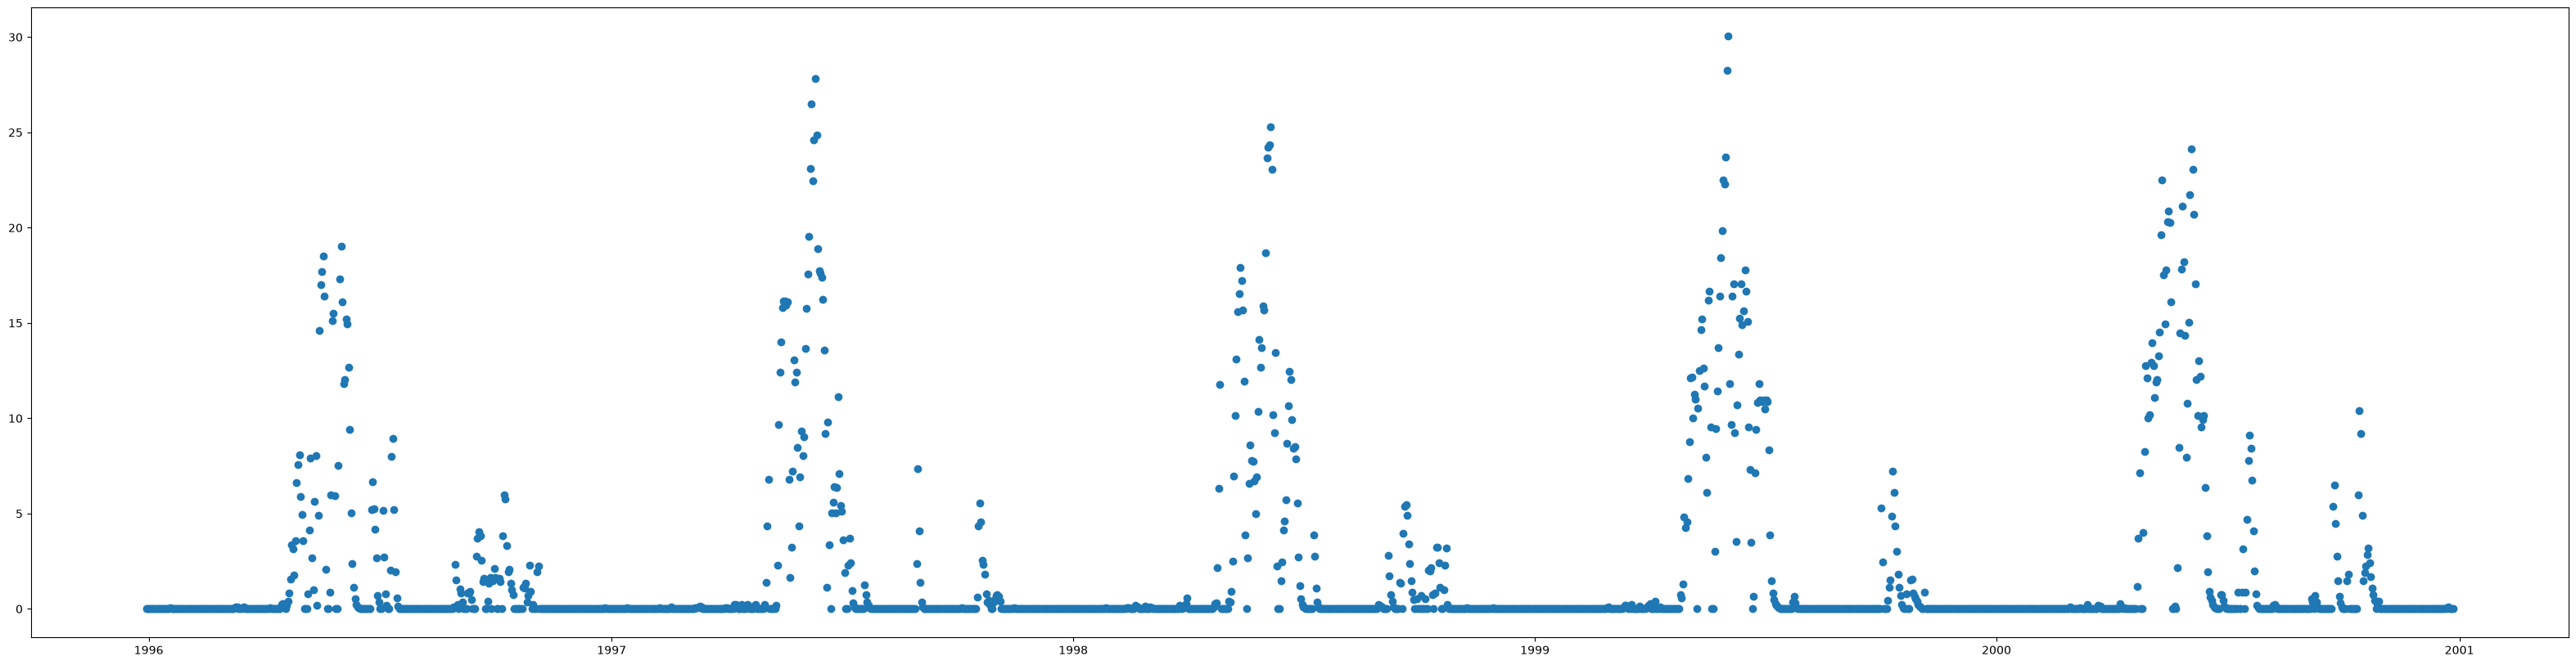

In [9]:
fig, ax = plt.subplots(figsize=(40,10))

sliced_df = vars_df.iloc[365*15:365*20,:]

ax.scatter(x=sliced_df.index, y=sliced_df.SNO)

In [10]:
vars_tg = td.DataFrame(data=vars_df.iloc[:365, :].to_numpy(), var_names=vars_df.columns)

## 1. Graph-Validation 

Check that the distribution is markov to the graph. 

In [11]:
# define tigramite graph and plot it 

N = len(vars_df.columns)
tau_max = 3

graph = np.zeros((N, N, tau_max + 1), dtype="<U3")
graph[:] = "" 

# variables are basinwise aggregates 

# temp 
graph[0, 0, 1] = "-->" # self causation
graph[0, 1, 0] = "-->" # impact on prec, if it gets hotter more water can be bound in air --> higher prec
graph[1, 0, 0] = "<--" # reverse
graph[0, 2, 0] = "-->" # higher temp, more et
graph[2, 0, 0] = "<--" # reverse
graph[0, 4, 0] = "-->" # impact on snowmelt
graph[4, 0, 0] = "<--" # reverse

# prec 
graph[1, 1, 1] = "-->" # self causation
graph[1, 2, 0] = "-->" # impact on et, instant
graph[2, 1, 0] = "<--" # reverse
graph[1, 3, 0] = "-->" # impact on sm, instant where water hits the ground it infiltrates
graph[3, 1, 0] = "<--" # reverse
graph[1, 5, 0] = "-->" # impact on q, instant
graph[5, 1, 0] = "<--" # reverse

# et 
graph[2, 2, 1] = "-->" # self causation
graph[2, 0, 1] = "-->" # impact on temp, lagged as basinwise it takes some time to cool it
graph[2, 1, 1] = "-->" # lagged impact on prec
graph[2, 3, 0] = "-->" # impact on sm, lagged because puddles get et'd before soil
graph[3, 2, 0] = "<--" # impact on sm, instant over basin
graph[2, 5, 0] = "-->" # impact on q
graph[5, 2, 0] = "<--" # reverse

# sm  
graph[3, 3, 1] = "-->" # self causation
graph[3, 2, 1] = "-->" # impact on et, lagged because soil moistru
graph[3, 5, 0] = "-->" # impact on q
graph[5, 3, 0] = "<--" # reverse

# snowmelt 
graph[4, 4, 1] = "-->" # self causation
graph[4, 2, 0] = "-->" # impact on et, more liquid water --> more et
graph[2, 4, 0] = "<--" # reverse
graph[4, 3, 0] = "-->" # impact on sm, more liquid water can infiltrate
graph[3, 4, 0] = "<--" # reverse
graph[4, 5, 1] = "-->" # impact on qobs 
#graph[5, 4, 0] = "<--" # reverse

# q
graph[5, 5, 1] = "-->" # self causation


(<Figure size 640x480 with 1 Axes>, <Axes: >)

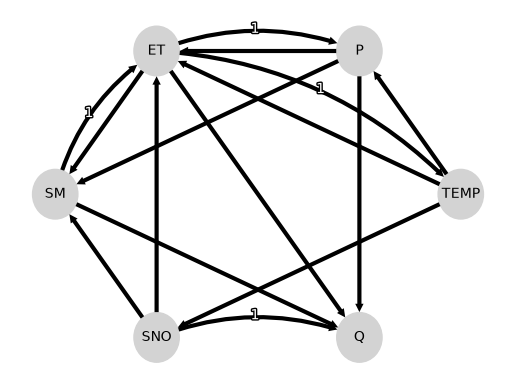

In [12]:
tp.plot_graph(
    graph=graph,
    var_names=vars_df.columns,
    arrow_linewidth=3
)

(<Figure size 640x480 with 1 Axes>, <Axes: >)

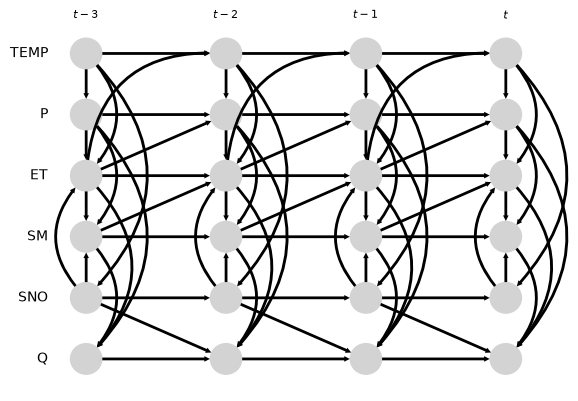

In [13]:
tp.plot_time_series_graph(graph=graph, var_names=vars_df.columns, curved_radius=0.5, arrow_linewidth=2)

Identify d-separation statement for all pairs of variables (incl. themselves)

snow t-1 --> qobs t (is there hidden confounding between these two?)

check snowmelt with all other varialbes 
qobs with all others 

investigate total_et

check collider: qobs t // sno t-2 | sno t-1
                qobs t // t t-1 | sno t-1

In [14]:
CI_config_dict = {

    (4,0) : {
        "X_dict": {
            (0, -1) : ["CMIknn", [(0, -2), (2, -1)]],
            (1, 0)  : ["CMIknn", [(0, 0), (1, -1), (2, -1)]],
            (2, -1) : ["CMIknn", [(0, -1), (1, -1), (2, -2), (3, -2), (4, -1)]], 
            (3, -1) : ["CMIknn", [(1, -1), (2, -1), (3, -2), (4, -1)]],
            (4, -2) : ["CMIknn", [(0, -2), (4, -3)]],
            (5, -1) : ["CMIknn", [(1, -1), (2, -1), (3, -1), (4, -2), (5, -2)]]
        },                   
        "Y_parents": [(0, 0), (4,-1)]
    },

    (5, 0) : {
        "X_dict": {
            (0, 0)  : ["CMIknn", [(0, -1), (2, -1)]],
            (1, -1) : ["CMIknn", [(0, -1), (1, -2), (2, -2)]],
            (2, -1) : ["CMIknn", [(0, -1), (1, -1), (2, -2), (3, -2), (4, -1)]], 
            (3, -1) : ["CMIknn", [(1, -1), (2, -1), (3, -2), (4, -1)]],
            (4, 0)  : ["CMIknn", [(0, -1), (4, -1)]],
            (5, -2) : ["CMIknn", [(1, -2), (2, -2), (3, -2), (4, -3), (5, -3)]]

        },
        "Y_parents" : [(1, 0), (2, 0), (3, 0), (4, -1), (5, -1)]
    }
}

with open("/home/wuhlmann/CS/causal_inference/snow_causal_inference/experiments/802/CI_config_dict.pkl", "wb") as f: 
    pickle.dump(CI_config_dict, file=f)

In [26]:
set(CI_config_dict[(4,0)]["Z"] + CI_config_dict[(4,0)]["X_dict"][(3,-1)][1])

{(0, 0), (1, -1), (2, -1), (3, -2), (4, -1)}

In [19]:
from tigramite.independence_tests.oracle_conditional_independence import OracleCI

oracle = OracleCI(graph=graph)

for Y_tuple in CI_config_dict: 

    # Tuples of Y as keys, and list holding CI_str, and later CI_results as values.
    X_dict = CI_config_dict[Y_tuple]["X_dict"]

    # Parents (list of tuples).
    Z = CI_config_dict[Y_tuple]["Z"]

    parents_str = ", ".join(f"{var_names[z[0]]} t_{z[1]}" for z in Z)

    print(f"\n --- Running CI tests for {var_names[Y_tuple[0]]} t_{Y_tuple[1]} with parents: {parents_str} ---")

    for X_tuple in X_dict:

        results = oracle.run_test(X=[X_tuple], Y=[Y_tuple], Z=Z, verbosity=1)#

        if not results == (1.0, 1.0): 

            print(f"{Y_tuple} not d-separated from {X_tuple} given {Z}.")


 --- Running CI tests for SNO t_0 with parents: TEMP t_0, SNO t_-1 ---
(4, 0) not d-separated from (0, -1) given [(0, 0), (4, -1)].
(4, 0) not d-separated from (1, 0) given [(0, 0), (4, -1)].
(4, 0) not d-separated from (2, -1) given [(0, 0), (4, -1)].
(4, 0) not d-separated from (3, -1) given [(0, 0), (4, -1)].
(4, 0) not d-separated from (4, -2) given [(0, 0), (4, -1)].
(4, 0) not d-separated from (5, -1) given [(0, 0), (4, -1)].

 --- Running CI tests for Q t_0 with parents: P t_0, ET t_0, SM t_0, SNO t_-1, Q t_-1 ---
(5, 0) not d-separated from (0, 0) given [(1, 0), (2, 0), (3, 0), (4, -1), (5, -1)].
(5, 0) not d-separated from (1, -1) given [(1, 0), (2, 0), (3, 0), (4, -1), (5, -1)].
(5, 0) not d-separated from (2, -1) given [(1, 0), (2, 0), (3, 0), (4, -1), (5, -1)].
(5, 0) not d-separated from (3, -1) given [(1, 0), (2, 0), (3, 0), (4, -1), (5, -1)].
(5, 0) not d-separated from (4, 0) given [(1, 0), (2, 0), (3, 0), (4, -1), (5, -1)].
(5, 0) not d-separated from (5, -2) given [(

In [16]:
CI_test_dict = {
    "ParCorr" : ParCorr(),
    "CMI" : CMIknn(knn=10)
}

var_names = vars_df.columns

for Y_tupel in CI_config_dict:

    X_dict = CI_config_dict[Y_tupel]["X_dict"]

    Z = CI_config_dict[Y_tupel]["Z"]

    parents_str = ", ".join(f"{var_names[z[0]]} t_{z[1]}" for z in Z)

    print(f"Running CI tests for {var_names[Y_tupel[0]]} t_{Y_tupel[1]} with parents: {parents_str}")

    for X_tuple in X_dict: 

        # Get the chosen CI test str.
        CI_str = X_dict[X_tuple][0]
        print(f"Using {CI_str} for {var_names[X_tuple[0]]} t_{X_tuple[1]}")

        # Run test.
        CI_test = CI_test_dict[CI_str]

        CI_test.set_dataframe(dataframe=vars_tg)

        results = CI_test.run_test(X=[X_tuple], Y=[Y_tupel], Z=Z, alpha_or_thres=0.01)
        print(f"\t {results}")

        # Save results to list of variable. 
        X_dict[X_tuple].append(results)

    # Replace pre-run Y_dict with post-run Y_dict. 
    CI_config_dict[Y_tupel]["Y_dict"] = Y_dict
    


Running CI tests for SNO t_0 with parents: TEMP t_0, SNO t_-1
Using CMI for TEMP t_-1
	 (np.float64(0.038472516632622966), 0.015968063872255488, False)
Using CMI for P t_0
	 (np.float64(0.049206432390065835), 0.005988023952095809, True)
Using CMI for ET t_-1
	 (np.float64(0.04811144668967371), 0.01996007984031936, False)
Using CMI for SM t_-1
	 (np.float64(0.02128001811138658), 0.3912175648702595, False)
Using CMI for SNO t_-2
	 (np.float64(0.009209540498786417), 0.7225548902195609, False)
Using CMI for Q t_-1
	 (np.float64(0.027769079384263762), 0.2654690618762475, False)
Running CI tests for Q t_0 with parents: P t_0, ET t_0, SM t_0, SNO t_-1, Q t_-1
Using CMI for TEMP t_0
	 (np.float64(0.026437828862249546), 0.13572854291417166, False)
Using CMI for P t_-1
	 (np.float64(0.012839824578496195), 0.8343313373253493, False)
Using CMI for ET t_-1
	 (np.float64(0.020117432643885103), 0.45708582834331335, False)
Using CMI for SM t_-1
	 (np.float64(0.01701429282255429), 0.9500998003992016, F

In [ ]:
# Plot snow vs parents
fig, axs = plt.subplots(1, 2, figsize=(6,3))

size = 1

axs[0].scatter(x=vars_df.TEMP, y=vars_df.SNO, s=size)
axs[0].set_xlabel("$Temp_t$")
axs[1].scatter(x=vars_df.SNO[:-1], y=vars_df.SNO[1:], s=size)
axs[1].set_xlabel("$Snowmelt_{t-1}$")

fig.suptitle("Snowmelt vs Parents")
#fig.supylabel("$Snowmelt_t$", rotation=0)
plt.tight_layout()

In [ ]:
# Plot snow vs others 

fig, axs = plt.subplots(1, 6, figsize=(30,5))

axs[0].scatter(x=vars_df.TEMP[:-1], y=vars_df.SNO[1:], s=size)
axs[0].set_xlabel("$Temp_{t-1}$")
axs[1].scatter(x=vars_df.P, y=vars_df.SNO, s=size)
axs[1].set_xlabel("$P_t$")
axs[2].scatter(x=vars_df.ET[:-1], y=vars_df.SNO[1:], s=size)
axs[2].set_xlabel("$ET_{t-1}$")
axs[3].scatter(x=vars_df.SM[:-1], y=vars_df.SNO[1:], s=size)
axs[3].set_xlabel("$SM_{t-1}$")
axs[4].scatter(x=vars_df.SNO[:-2], y=vars_df.SNO[2:], s=size)
axs[4].set_xlabel("$Snowmelt_{t-2}$")
axs[5].scatter(x=vars_df.Q[:-1], y=vars_df.SNO[1:], s=size)
axs[5].set_xlabel("$Q_{t-1}$")


fig.suptitle("Snowmelt vs others")
#fig.supylabel("$Snowmelt_t$")
plt.tight_layout()

In [ ]:
# plot qobs vs parents
fig, axs = plt.subplots(1, 5, figsize=(25,5))

axs[0].scatter(x=vars_df.P, y=vars_df.Q, s=size)
axs[0].set_xlabel("$P_t$")
axs[1].scatter(x=vars_df.ET, y=vars_df.Q, s=size)
axs[1].set_xlabel("$ET_t$")
axs[2].scatter(x=vars_df.SM, y=vars_df.Q, s=size)
axs[2].set_xlabel("$SM_t$")
axs[3].scatter(x=vars_df.SNO[:-1], y=vars_df.Q[1:], s=size)
axs[3].set_xlabel("$Snowmelt_{t-1}$")
axs[4].scatter(x=vars_df.Q[:-1], y=vars_df.Q[1:], s=size)
axs[4].set_xlabel("$Q_{t-1}$")

fig.suptitle("Discharge vs Parents")
fig.supylabel("$Q_t$", rotation=0)
plt.tight_layout()


In [ ]:
# Plot discharge vs others 

fig, axs = plt.subplots(1, 6, figsize=(30,5))

axs[0].scatter(x=vars_df.TEMP, y=vars_df.Q, s=size)
axs[0].set_xlabel("$Temp_t$")
axs[1].scatter(x=vars_df.P[:-1], y=vars_df.Q[1:], s=size)
axs[1].set_xlabel("$P_{t-1}$")
axs[2].scatter(x=vars_df.ET[:-1], y=vars_df.Q[1:], s=size)
axs[2].set_xlabel("$ET_{t-1}$")
axs[3].scatter(x=vars_df.SM[:-1], y=vars_df.SNO[1:], s=size)
axs[3].set_xlabel("$SM_{t-1}$")
axs[4].scatter(x=vars_df.SNO, y=vars_df.Q, s=size)
axs[4].set_xlabel("$Snowmelt_t$")
axs[5].scatter(x=vars_df.Q[:-2], y=vars_df.Q[2:], s=size)
axs[5].set_xlabel("$Q_{t-2}$")


fig.suptitle("Discharge vs others")
#fig.supylabel("$Snowmelt_t$")
plt.tight_layout()

## 2. Causal Effect Estimation

In [ ]:
X = [(4, -1)]
Y = [(5, 0)]
causal_effects = CausalEffects(graph=graph, graph_type="stationary_dag", X=X, Y=Y, check_SM_overlap=True, verbosity=1)

In [ ]:
opt = causal_effects.get_optimal_set()
print("Oset = ", [(vars_df.columns[v[0]], v[1]) for v in opt])

In [ ]:
special_nodes = {}
for node in causal_effects.X:
    special_nodes[node] = 'red'
for node in causal_effects.Y:
    special_nodes[node] = 'blue'
for node in opt:
    special_nodes[node] = 'orange'
for node in causal_effects.M:
    special_nodes[node] = 'lightblue'

tp.plot_time_series_graph(graph = graph,
        var_names=vars_df.columns, 
#         save_name='Example.pdf',
        figsize = (8, 6),
        special_nodes=special_nodes,
        )

In [ ]:
optimality = causal_effects.check_optimality()
print("(Graph, X, Y, S) fulfills optimality: ", optimality)

In [ ]:
causal_effects.fit_total_effect(
    dataframe=vars_tg,
    estimator=RandomForestRegressor(),
    adjustment_set="optimal",
)

In [ ]:
causal_effects.model.fit_results["model"]

In [ ]:
vars_df.iloc[:365, :].SNO.describe()

In [ ]:
intervention_data = 2*np.ones((1, 1))
y1 = causal_effects.predict_total_effect( 
        intervention_data=intervention_data,
        )
print("y1 = ",y1)

intervention_data = 13.*np.ones((1, 1))
y2 = causal_effects.predict_total_effect( 
        intervention_data=intervention_data,
        )
print("y2 = ",y2)

In [ ]:
intervention_data = np.linspace(0, 7, 20).reshape(20, 1)
estimated_causal_effects = causal_effects.predict_total_effect( 
        intervention_data=intervention_data,
        )
plt.scatter(intervention_data[:,0], estimated_causal_effects, label="Estimated")
plt.xlabel('Intervention / X-value range')
plt.ylabel('Causal effect')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from itertools import product
 
from tigramite.independence_tests.oracle_conditional_independence import OracleCI
from tigramite import data_processing as pp
 
 
def get_parents(graph, tau_max, var, lag):
    """Eltern von Knoten (var, lag) im stationären Graphen."""
    N = graph.shape[0]
    parents = []
    for i in range(N):
        for tau in range(0, tau_max + 1):
            if graph[i, var, tau] == "-->":
                parents.append((i, lag - tau))
    return parents
 
 
def edge_exists(graph, tau_max, i, li, j, lj):
    """Gibt es eine direkte Kante zwischen (i, li) und (j, lj)?"""
    diff = lj - li
    if 0 <= diff <= tau_max and graph[i, j, diff] == "-->":
        return True
    diff2 = li - lj
    if 0 <= diff2 <= tau_max and graph[j, i, diff2] == "-->":
        return True
    return False
 
 
def check_markov(graph, vars_df, tau_max, cond_ind_test, window=None, alpha=0.05, verbosity=0):
    """
    Leitet für alle nicht-adjazenten Paare (X, Y=(j,0)) die
    Eltern-basierte Trennmenge ab, bestätigt sie mit OracleCI und
    testet sie anschließend mit test auf den echten Daten.
 
    window : wie weit X in die Vergangenheit zurückreicht (Default: 2*tau_max)
    alpha  : Signifikanzniveau für den echten CI-Test
 
    Returns
    -------
    results : pandas.DataFrame mit einer Zeile pro getestetem Tripel
    """
    N = graph.shape[0]
    var_names = list(vars_df.columns)
    if window is None:
        window = 2 * tau_max if tau_max > 0 else 1
 
    oracle = OracleCI(graph=graph)
    dataframe = pp.DataFrame(vars_df.values, var_names=var_names)
    test = cond_ind_test
    test.set_dataframe(dataframe)
 
    rows = []
    for j in range(N):  # Zielvariable Y
        Y = [(j, 0)]
        Pa_Y = get_parents(graph, tau_max, j, 0)
        print(Y)
 
        for i, tau in product(range(N), range(0, window + 1)):
            X_node = (i, -tau)
            if X_node == (j, 0):
                continue
            if edge_exists(graph, tau_max, i, -tau, j, 0):
                continue  # direkt verbunden -> keine Implikation zu testen
 
            X = [X_node]
            Pa_X = get_parents(graph, tau_max, i, -tau)
            Z = sorted(set(Pa_X) | set(Pa_Y) - {X_node, (j, 0)})
 
            # 1) Gegenprüfung: separiert Z laut Graph tatsächlich X und Y?
            max_abs_lag = max([abs(l) for _, l in [X_node, (j, 0)] + Z] + [tau_max])
            _, oracle_pval = oracle.run_test(X=X, Y=Y, Z=Z, tau_max=max_abs_lag)
            if oracle_pval != 1.0:
                continue  # keine gültige Implikation mit dieser Z-Wahl
 
            # 2) Echter Test auf den Daten
            val, pval = test.run_test(X=X, Y=Y, Z=Z, tau_max=max_abs_lag)
 
            rows.append({
                "X": f"{var_names[i]}(t-{tau})" if tau else f"{var_names[i]}(t)",
                "Y": f"{var_names[j]}(t)",
                "|Z|": len(Z),
                "val": round(val, 3),
                "pval": round(pval, 4),
                "verletzt (p<alpha)": pval < alpha,
            })
 
            if verbosity:
                print(f"{var_names[i]}(t-{tau}) _||_ {var_names[j]}(t) | "
                      f"{len(Z)} Vars  ->  pval={pval:.4f}")
 
    results = pd.DataFrame(rows)
    return results
  

In [ ]:
#res = check_markov(graph=graph, vars_df=vars_df.dropna(), cond_ind_test=ParCorrWLS(), tau_max=1, verbosity=1)

In [ ]:
#res[res["verletzt (p<alpha)"]]